# MACHINE LEARNING MODEL TRAINING SCRIPT(SUPPORT VECTOR MACHINE) - BY EYONG-EBOB CYRIL ENOW

# Problem statement
This project seeks to use support vector machine (SVM) algorithm predict accident severity in Malta, based on some features or factors from press release and police report data sources. Based on this data, the model will classify accidents into 5 severity categories namely; None, Minor, Serious, Fatal, Critical. The main objective is to identify the factors that could influence the severity of an accident. This will help the goverment to create road safety policies, identify dangerous conditions, and high-risk areas and time where accidents are prone to occur.

# Data Processing

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [39]:
# Load the dataset
df = pd.read_csv('data/dataset.csv')

In [41]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (682, 24)


In [43]:
print(df.head())

   person_id  article_id   age  gender severity is_driver vehicle_type  \
0          0        4208  78.0    male     none      True          car   
1          1        4093  54.0    male  serious      True   motorcycle   
2          2        4110  54.0    male  serious      True   motorcycle   
3          3        4066  17.0  female  serious     False          NaN   
4          4        4066  52.0    male     none      True          car   

  person_state  accident_id            date_time  ... windspeed_10m  \
0          NaN          0.0  2024-12-04 17:00:00  ...           9.8   
1          NaN          1.0  2024-12-11 17:00:00  ...           6.5   
2          NaN          2.0  2024-12-11 13:00:00  ...           5.0   
3          NaN          3.0  2024-12-13 17:30:00  ...          24.0   
4          NaN          3.0  2024-12-13 17:30:00  ...          24.0   

  cloud_cover  weather_code  is_weekday  is_public_holiday  time_of_day  \
0       100.0           3.0        True              

In [44]:
print(f"\nColumns: {df.columns.tolist()}")


Columns: ['person_id', 'article_id', 'age', 'gender', 'severity', 'is_driver', 'vehicle_type', 'person_state', 'accident_id', 'date_time', 'accident_type', 'location', 'temperature_2m', 'precipitation', 'windspeed_10m', 'cloud_cover', 'weather_code', 'is_weekday', 'is_public_holiday', 'time_of_day', 'month', 'hour', 'day', 'year']


In [45]:
df.drop('person_id', inplace=True, axis=1)
df.drop('article_id', inplace=True, axis=1)
df.drop('accident_id', inplace=True, axis=1)
df.drop('date_time', inplace=True, axis=1)
df.drop('weather_code', inplace=True, axis=1)

In [46]:
print(f"\nColumns: {df.columns.tolist()}")


Columns: ['age', 'gender', 'severity', 'is_driver', 'vehicle_type', 'person_state', 'accident_type', 'location', 'temperature_2m', 'precipitation', 'windspeed_10m', 'cloud_cover', 'is_weekday', 'is_public_holiday', 'time_of_day', 'month', 'hour', 'day', 'year']


In [47]:
# Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
age                   64
gender               101
severity              21
is_driver              4
vehicle_type         114
person_state         665
accident_type          0
location              39
temperature_2m         0
precipitation          0
windspeed_10m          0
cloud_cover            0
is_weekday             0
is_public_holiday      0
time_of_day           80
month                  0
hour                  80
day                    0
year                   0
dtype: int64


In [48]:
# Check target variable
if 'Severity' in df.columns:
    target_col = 'Severity'
elif 'severity' in df.columns:
    target_col = 'severity'
# Find target column (assuming it contains 'severity' in name)
    target_cols = [col for col in df.columns if 'severity' in col.lower()]
    target_col = target_cols[0] if target_cols else df.columns[-1]

In [49]:
print(f"\nTarget column: {target_col}")
print(f"Target distribution:")
print(df[target_col].value_counts())
print(f"\nTarget percentages:")
print(df[target_col].value_counts(normalize=True) * 100)


Target column: severity
Target distribution:
severity
none        280
serious     254
fatal        82
minor        44
critical      1
Name: count, dtype: int64

Target percentages:
severity
none        42.360061
serious     38.426626
fatal       12.405446
minor        6.656581
critical     0.151286
Name: proportion, dtype: float64


# Data cleaning

In [50]:
# Make a copy
df_clean = df.copy()

In [51]:
# Handle missing values - simple approach
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype == 'object':
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

print("Missing values handled!")
print(f"\nMissing values per column after imputation:")
print(df_clean.isnull().sum())

Missing values handled!

Missing values per column after imputation:
age                  0
gender               0
severity             0
is_driver            0
vehicle_type         0
person_state         0
accident_type        0
location             0
temperature_2m       0
precipitation        0
windspeed_10m        0
cloud_cover          0
is_weekday           0
is_public_holiday    0
time_of_day          0
month                0
hour                 0
day                  0
year                 0
dtype: int64


In [52]:
# Remove duplicate rows
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {initial_rows - len(df_clean)} duplicate rows")

Removed 27 duplicate rows


# Features Selection

In [53]:
# Separate features and target
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

In [54]:
# Convert categorical columns to numeric
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded: {col}")

Encoded: gender
Encoded: vehicle_type
Encoded: person_state
Encoded: accident_type
Encoded: location
Encoded: time_of_day


In [55]:
# Encode target if it's categorical
if y.dtype == 'object':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)
    print(f"Target classes: {le_target.classes_}")


Target classes: ['critical' 'fatal' 'minor' 'none' 'serious']


# TRAIN-TEST SPLIT

In [56]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=None
    )

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")



Training set: (524, 18)
Test set: (131, 18)


# Feature Scalling

In [57]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeatures scaled!")


Features scaled!


# BUILD AND TRAIN SVM MODEL

In [ ]:
#  SVM model 
print("Training baseline SVM model...")
svm_baseline = SVC(
    kernel='rbf', 
    random_state=42, 
    probability=True
)
svm_baseline.fit(X_train_scaled, y_train)

# Make predictions
y_pred = svm_baseline.predict(X_test_scaled)

# Evaluate baseline
print(f"\nBaseline Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Training baseline SVM model...

Baseline Model Accuracy: 0.5725

Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        15
           2       0.50      0.20      0.29         5
           3       0.60      0.77      0.68        64
           4       0.52      0.53      0.53        47

    accuracy                           0.57       131
   macro avg       0.41      0.37      0.37       131
weighted avg       0.50      0.57      0.53       131



# HYPERPARAMETER TUNING

In [59]:
# Simple tuning with fewer parameters for speed
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear']
}

print("Tuning SVM parameters...")

# Use all data or sample based on size
if len(X_train_scaled) > 5000:
    print("Using sample for faster tuning...")
    sample_idx = np.random.choice(len(X_train_scaled), min(3000, len(X_train_scaled)), replace=False)
    X_tune = X_train_scaled[sample_idx]
    y_tune = y_train[sample_idx]
else:
    X_tune = X_train_scaled
    y_tune = y_train

svm_tuned = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0  # Set to 1 if you want to see progress
)
svm_tuned.fit(X_tune, y_tune)

Tuning SVM parameters...


GridSearchCV(cv=3, estimator=SVC(probability=True, random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']},
             scoring='accuracy')

In [60]:
print(f"\nBest parameters: {svm_tuned.best_params_}")
print(f"Best CV score: {svm_tuned.best_score_:.4f}")


Best parameters: {'C': 10, 'kernel': 'rbf'}
Best CV score: 0.5439


# Final Model Evaluation

In [61]:
# Train final model with best parameters on full data
final_model = SVC(
    **svm_tuned.best_params_,
    random_state=42,
    probability=True
)
final_model.fit(X_train_scaled, y_train)

# Final predictions
y_pred_final = final_model.predict(X_test_scaled)

print(f"\nFinal Model Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_final, zero_division=0))


Final Model Accuracy: 0.5725

Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.25      0.20      0.22        15
           2       0.40      0.40      0.40         5
           3       0.66      0.66      0.66        64
           4       0.56      0.60      0.58        47

    accuracy                           0.57       131
   macro avg       0.47      0.46      0.46       131
weighted avg       0.57      0.57      0.57       131



Text(0.5, 1.0, 'Confusion Matrix - Final SVM Model')

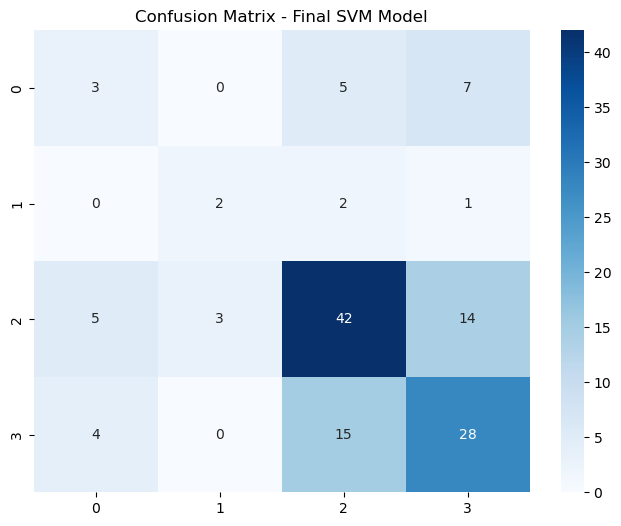

In [62]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Final SVM Model')


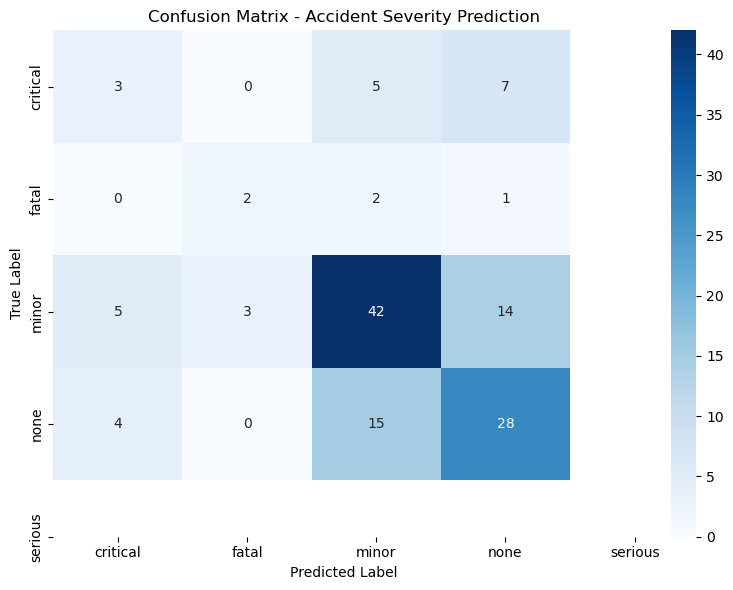

In [63]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)

# Create labels for confusion matrix
if 'le_target' in locals():
    labels = le_target.classes_
else:
    labels = [str(i) for i in range(len(np.unique(y)))]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Accident Severity Prediction')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

# FEATURE IMPORTANCE

In [64]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

r = permutation_importance(
    final_model, X_test_scaled, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

importance = r.importances_mean

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))


Top 10 Most Important Features:
              Feature  Importance
3        vehicle_type    0.124427
2           is_driver    0.074809
0                 age    0.050382
15               hour    0.025954
17               year    0.017557
9       windspeed_10m    0.007634
8       precipitation    0.006870
12  is_public_holiday    0.004580
13        time_of_day    0.001527
4        person_state    0.000000


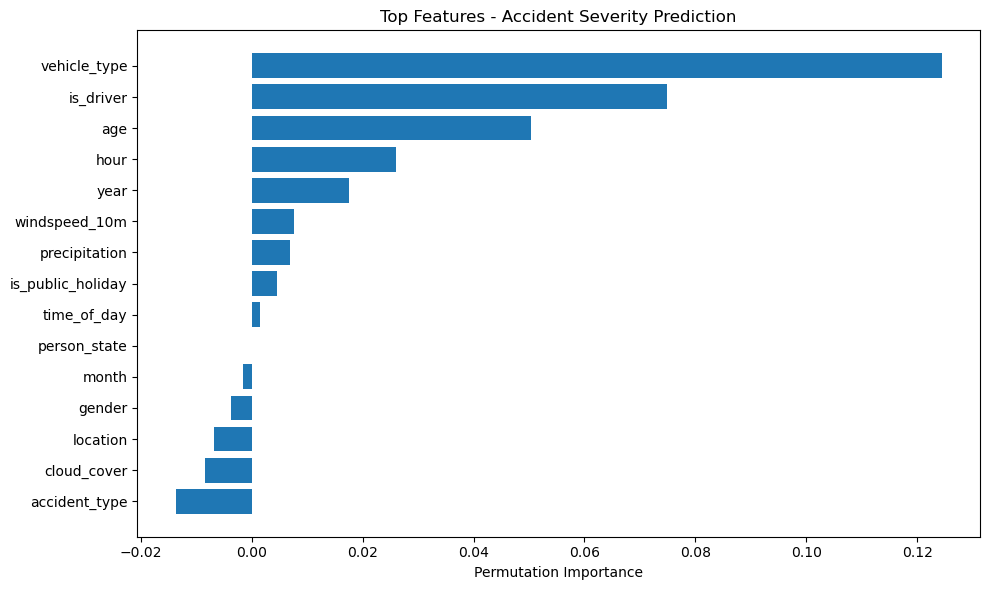

In [65]:
import matplotlib.pyplot as plt

top_n = min(15, len(feature_importance))
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'].head(top_n)[::-1],
         feature_importance['Importance'].head(top_n)[::-1])
plt.xlabel("Permutation Importance")
plt.title("Top Features - Accident Severity Prediction")
plt.tight_layout()
plt.show()

In [66]:
# Total importance
total_importance = feature_importance['Importance'].sum()

# Add percentage column
feature_importance['Contribution_%'] = (
    feature_importance['Importance'] / total_importance
) * 100

# Sort again just in case
feature_importance = feature_importance.sort_values('Contribution_%', ascending=False)

# Show top 10 with percentages
print(feature_importance.head(10))

              Feature  Importance  Contribution_%
3        vehicle_type    0.124427       56.993007
2           is_driver    0.074809       34.265734
0                 age    0.050382       23.076923
15               hour    0.025954       11.888112
17               year    0.017557        8.041958
9       windspeed_10m    0.007634        3.496503
8       precipitation    0.006870        3.146853
12  is_public_holiday    0.004580        2.097902
13        time_of_day    0.001527        0.699301
4        person_state    0.000000        0.000000
